In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(data.head())
print("\nShape:", data.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [7]:
print(data["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [8]:
churn_percentage = data["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [9]:
print(data.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [10]:
print(data.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [11]:
print(data.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [12]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

print("Missing TotalCharges:", data["TotalCharges"].isnull().sum())

Missing TotalCharges: 11


In [13]:
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

print("Missing TotalCharges after cleaning:", data["TotalCharges"].isnull().sum())

Missing TotalCharges after cleaning: 0


In [14]:
print(pd.crosstab(data["gender"], data["Churn"]))

Churn     No  Yes
gender           
Female  2549  939
Male    2625  930


In [15]:
print(pd.crosstab(data["Contract"], data["Churn"]))

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


In [16]:
print(pd.crosstab(data["InternetService"], data["Churn"]))

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


In [17]:
print(pd.crosstab(data["PaymentMethod"], data["Churn"]))

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


In [18]:
print(data.groupby("Churn")["tenure"].mean())

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [19]:
print(data.groupby("Churn")["MonthlyCharges"].mean())

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [20]:
print(pd.crosstab(data["SeniorCitizen"], data["Churn"]))

Churn            No   Yes
SeniorCitizen            
0              4508  1393
1               666   476


In [21]:
print(pd.crosstab(data["Dependents"], data["Churn"]))

Churn         No   Yes
Dependents            
No          3390  1543
Yes         1784   326


In [22]:
print(pd.crosstab(data["Partner"], data["Churn"]))

Churn      No   Yes
Partner            
No       2441  1200
Yes      2733   669


In [23]:
print(pd.crosstab(data["TechSupport"], data["Churn"]))

Churn                  No   Yes
TechSupport                    
No                   2027  1446
No internet service  1413   113
Yes                  1734   310


In [24]:
print(pd.crosstab(data["OnlineSecurity"], data["Churn"]))

Churn                  No   Yes
OnlineSecurity                 
No                   2037  1461
No internet service  1413   113
Yes                  1724   295


In [25]:
print(pd.crosstab(data["PaperlessBilling"], data["Churn"]))

Churn               No   Yes
PaperlessBilling            
No                2403   469
Yes               2771  1400


In [26]:
print(pd.crosstab(
    [data["Contract"], data["InternetService"]],
    data["Churn"]
))

Churn                            No   Yes
Contract       InternetService           
Month-to-month DSL              829   394
               Fiber optic      966  1162
               No               425    99
One year       DSL              517    53
               Fiber optic      435   104
               No               355     9
Two year       DSL              616    12
               Fiber optic      398    31
               No               633     5


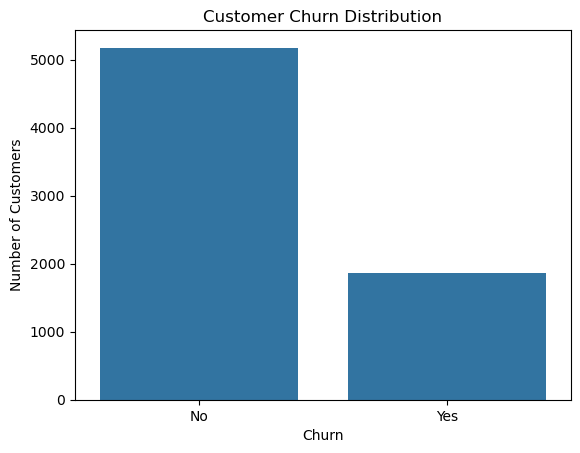

In [27]:
sns.countplot(data=data, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

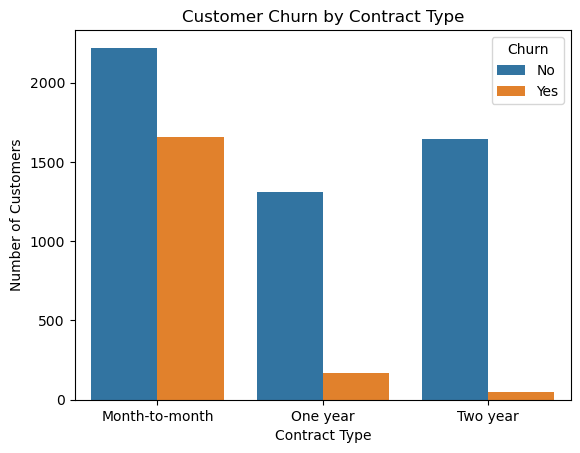

In [28]:
sns.countplot(data=data, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

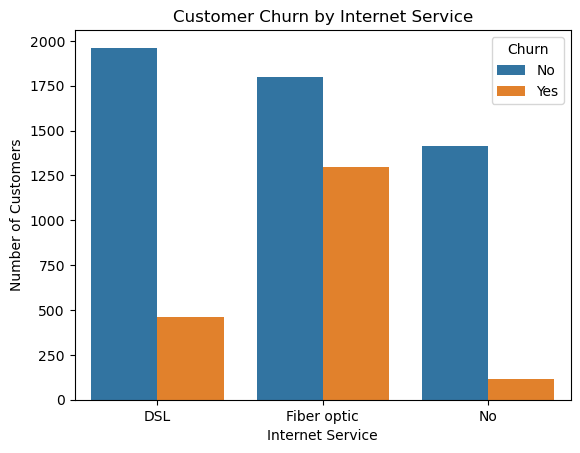

In [29]:
sns.countplot(data=data, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

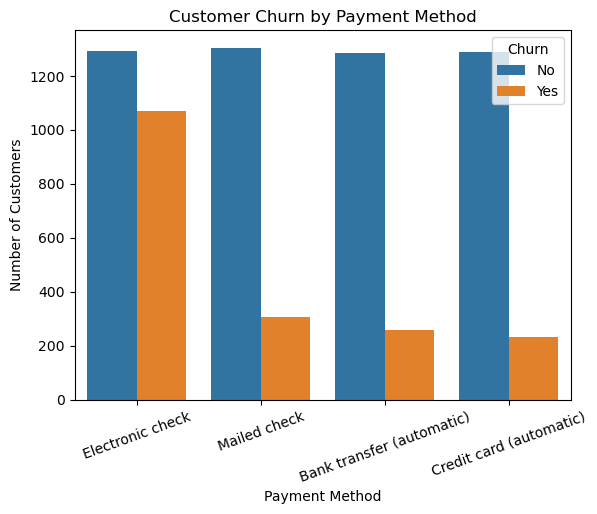

In [30]:
sns.countplot(data=data, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

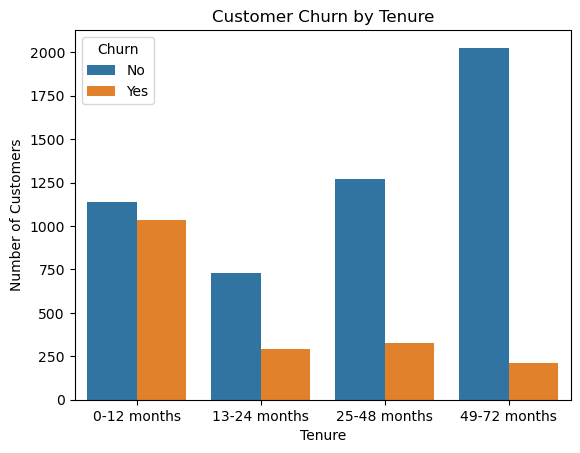

In [31]:
data["TenureGroup"] = pd.cut(
    data["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

sns.countplot(data=data, x="TenureGroup", hue="Churn")

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.show()

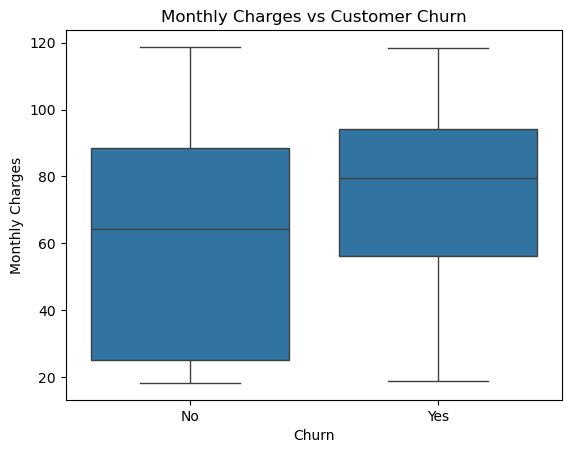

In [32]:
sns.boxplot(data=data, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

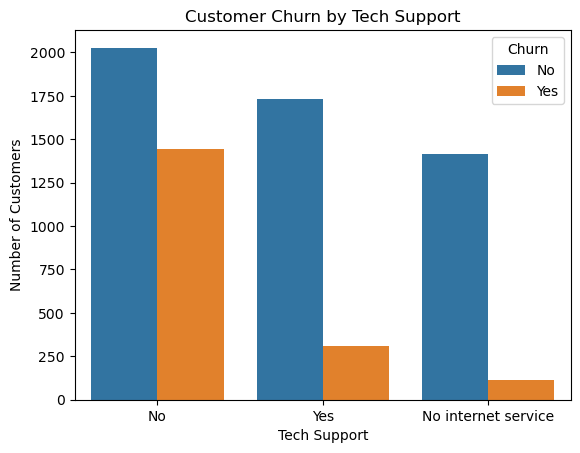

In [33]:
sns.countplot(data=data, x="TechSupport", hue="Churn")

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.show()

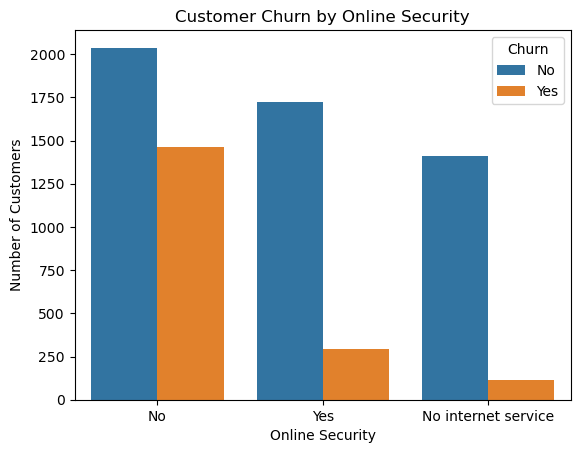

In [34]:
sns.countplot(data=data, x="OnlineSecurity", hue="Churn")

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.show()

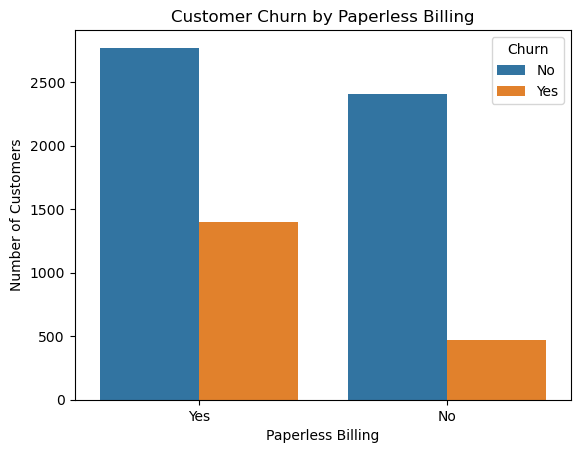

In [35]:
sns.countplot(data=data, x="PaperlessBilling", hue="Churn")

plt.title("Customer Churn by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")
plt.show()

In [36]:
data.to_csv("../data/processed/cleaned_customer_churn.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [37]:
churn_summary = data["Churn"].value_counts(normalize=True).reset_index()

churn_summary.columns = ["Churn", "Percentage"]

churn_summary["Percentage"] = churn_summary["Percentage"] * 100

print(churn_summary)

  Churn  Percentage
0    No   73.463013
1   Yes   26.536987


In [38]:
churn_summary.to_csv(
    "../data/processed/churn_summary.csv",
    index=False
)

print("Churn summary saved successfully!")

Churn summary saved successfully!


In [39]:
contract_churn = pd.crosstab(
    data["Contract"],
    data["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [40]:
internet_churn = pd.crosstab(
    data["InternetService"],
    data["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [41]:
payment_churn = pd.crosstab(
    data["PaymentMethod"],
    data["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [42]:
techsupport_churn = pd.crosstab(
    data["TechSupport"],
    data["Churn"],
    normalize="index"
) * 100

print(techsupport_churn)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


In [43]:
security_churn = pd.crosstab(
    data["OnlineSecurity"],
    data["Churn"],
    normalize="index"
) * 100

print(security_churn)

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


In [44]:
senior_churn = pd.crosstab(
    data["SeniorCitizen"],
    data["Churn"],
    normalize="index"
) * 100

print(senior_churn)

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


In [45]:
partner_churn = pd.crosstab(
    data["Partner"],
    data["Churn"],
    normalize="index"
) * 100

print(partner_churn)

Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903


In [46]:
dependents_churn = pd.crosstab(
    data["Dependents"],
    data["Churn"],
    normalize="index"
) * 100

print(dependents_churn)

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.825464
MonthlyCharges  0.247900        1.000000      0.650864
TotalCharges    0.825464        0.650864      1.000000


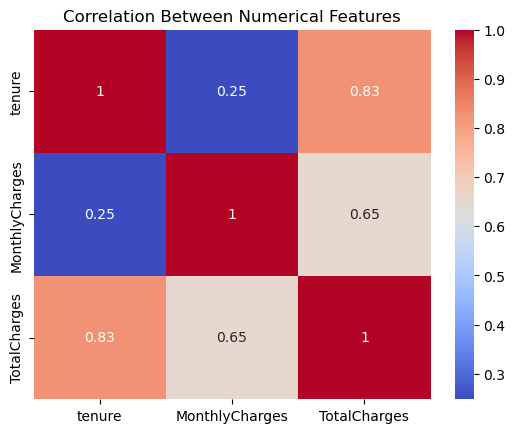

In [47]:
numeric_data = data[["tenure", "MonthlyCharges", "TotalCharges"]]

correlation = numeric_data.corr()

print(correlation)

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Between Numerical Features")
plt.show()

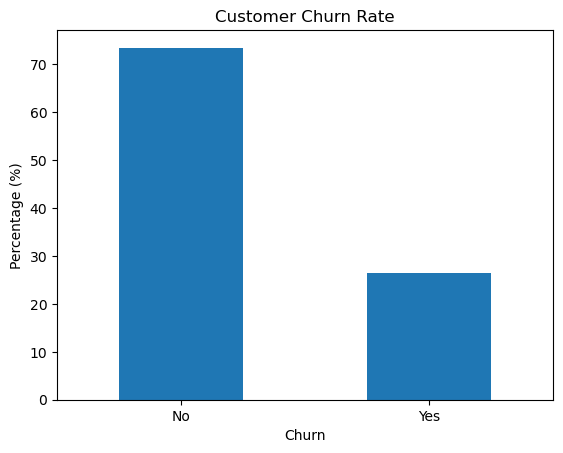

In [48]:
churn_rate = data["Churn"].value_counts(normalize=True) * 100

churn_rate.plot(kind="bar")

plt.title("Customer Churn Rate")
plt.xlabel("Churn")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.show()

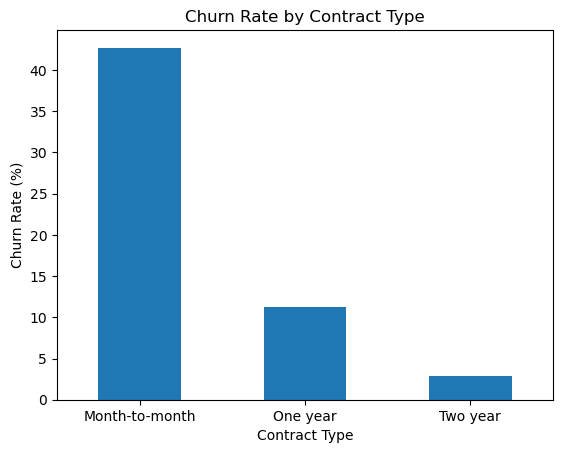

In [49]:
contract_churn_rate = pd.crosstab(
    data["Contract"],
    data["Churn"],
    normalize="index"
) * 100

contract_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

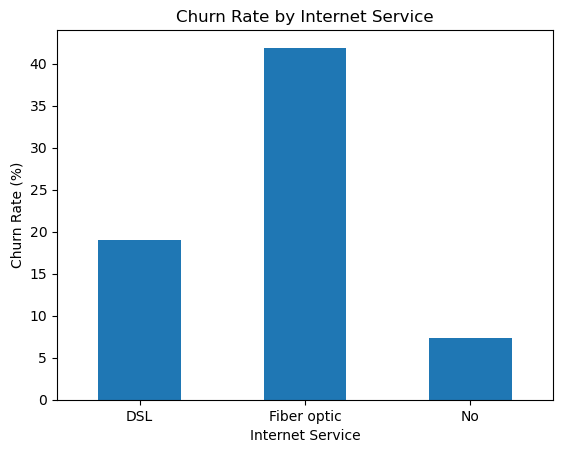

In [50]:
internet_churn_rate = pd.crosstab(
    data["InternetService"],
    data["Churn"],
    normalize="index"
) * 100

internet_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

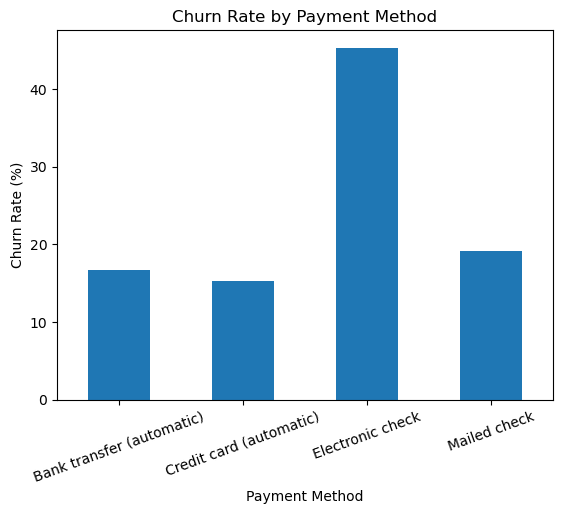

In [51]:
payment_churn_rate = pd.crosstab(
    data["PaymentMethod"],
    data["Churn"],
    normalize="index"
) * 100

payment_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

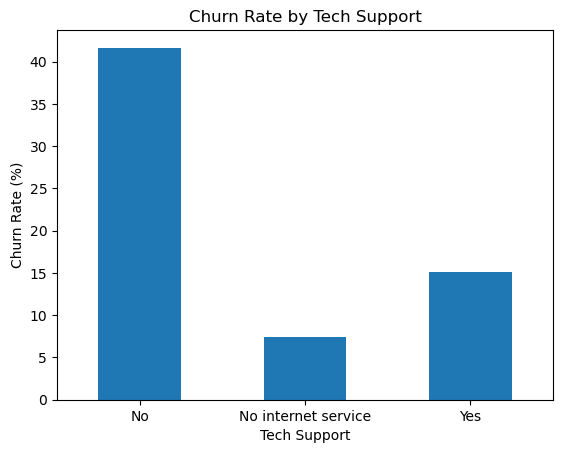

In [52]:
techsupport_churn_rate = pd.crosstab(
    data["TechSupport"],
    data["Churn"],
    normalize="index"
) * 100

techsupport_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

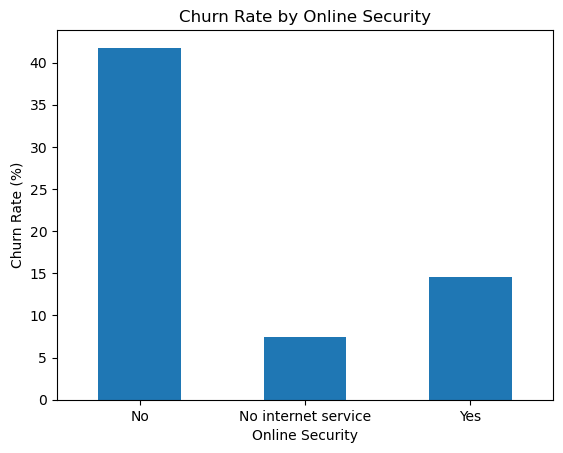

In [53]:
security_churn_rate = pd.crosstab(
    data["OnlineSecurity"],
    data["Churn"],
    normalize="index"
) * 100

security_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

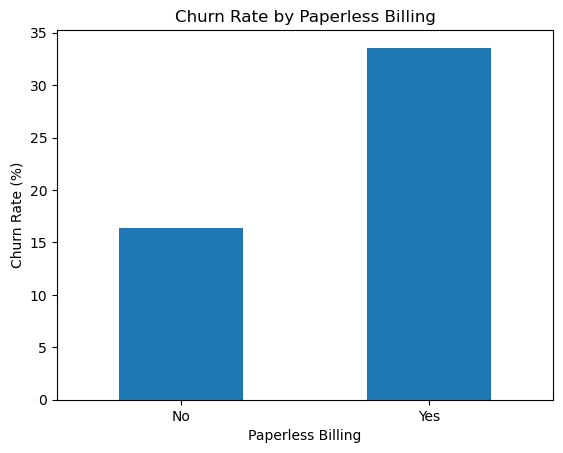

In [54]:
paperless_churn_rate = pd.crosstab(
    data["PaperlessBilling"],
    data["Churn"],
    normalize="index"
) * 100

paperless_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

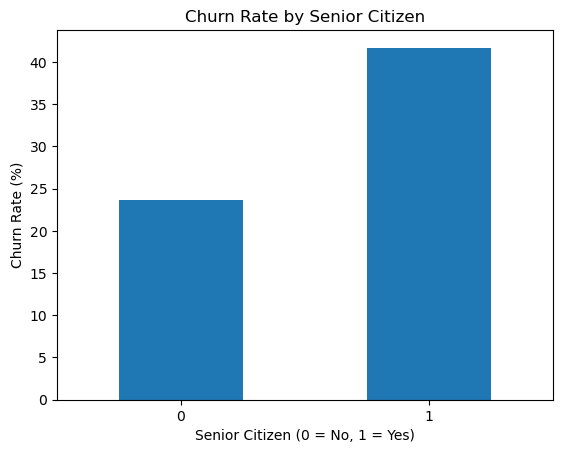

In [55]:
senior_churn_rate = pd.crosstab(
    data["SeniorCitizen"],
    data["Churn"],
    normalize="index"
) * 100

senior_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

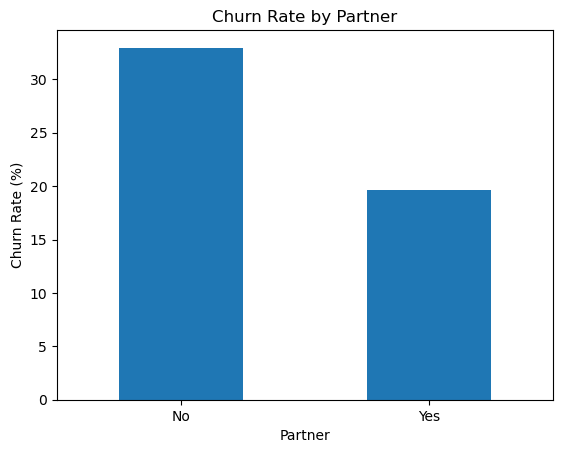

In [56]:
partner_churn_rate = pd.crosstab(
    data["Partner"],
    data["Churn"],
    normalize="index"
) * 100

partner_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Partner")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

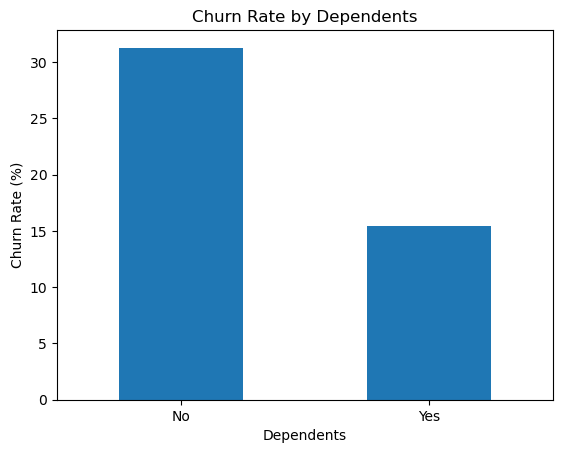

In [57]:
dependents_churn_rate = pd.crosstab(
    data["Dependents"],
    data["Churn"],
    normalize="index"
) * 100

dependents_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [58]:
data["ChurnBinary"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(data[["Churn", "ChurnBinary"]].head())

  Churn  ChurnBinary
0    No            0
1    No            0
2   Yes            1
3    No            0
4   Yes            1


In [59]:
X = data.drop(columns=["customerID", "Churn", "ChurnBinary"])
y = data["ChurnBinary"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 20)
Target: (7043,)


In [60]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded features:", X.shape)

Encoded features: (7043, 33)


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 33)
Testing data: (1409, 33)


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Scaling completed successfully!
Training data shape: (5634, 33)
Testing data shape: (1409, 33)


In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [64]:
y_pred = model.predict(X_test_scaled)

print("Predictions completed successfully!")
print(y_pred[:10])

Predictions completed successfully!
[0 1 0 0 0 1 0 0 0 0]


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

Accuracy : 79.91 %
Precision: 65.22 %
Recall   : 52.14 %
F1 Score : 57.95 %


In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[931 104]
 [179 195]]


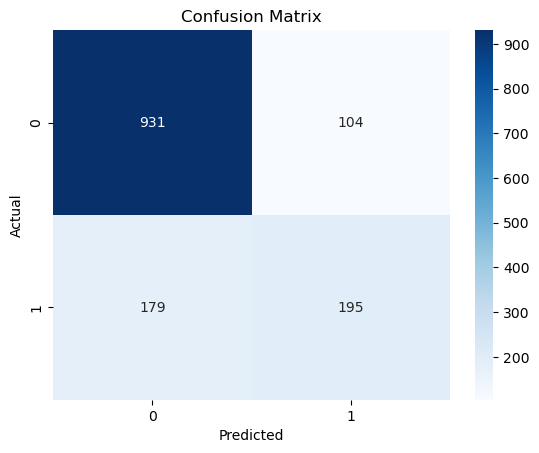

In [67]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [68]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

feature_importance["AbsoluteImportance"] = (
    feature_importance["Importance"].abs()
)

feature_importance = feature_importance.sort_values(
    "AbsoluteImportance",
    ascending=False
)

print(feature_importance.head(10))

                        Feature  Importance  AbsoluteImportance
1                        tenure   -1.150776            1.150776
2                MonthlyCharges   -0.816677            0.816677
10  InternetService_Fiber optic    0.770543            0.770543
25            Contract_Two year   -0.635276            0.635276
24            Contract_One year   -0.293697            0.293697
21              StreamingTV_Yes    0.262648            0.262648
23          StreamingMovies_Yes    0.261956            0.261956
9             MultipleLines_Yes    0.234968            0.234968
32     TenureGroup_49-72 months    0.233242            0.233242
3                  TotalCharges    0.196849            0.196849


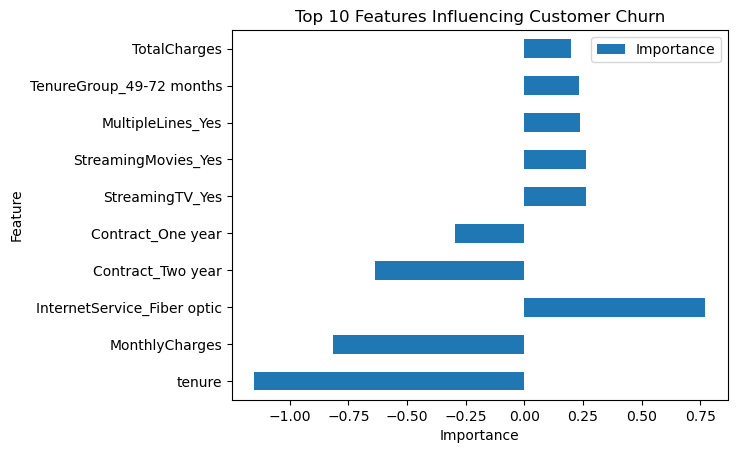

In [69]:
top_features = feature_importance.head(10)

top_features.plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [71]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions completed!")
print(rf_pred[:10])

Random Forest predictions completed!
[0 1 0 0 0 0 0 0 0 0]


In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Random Forest Precision:", round(rf_precision * 100, 2), "%")
print("Random Forest Recall   :", round(rf_recall * 100, 2), "%")
print("Random Forest F1 Score :", round(rf_f1 * 100, 2), "%")

Random Forest Accuracy : 78.85 %
Random Forest Precision: 62.93 %
Random Forest Recall   : 49.47 %
Random Forest F1 Score : 55.39 %


In [73]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1 Score": [f1, rf_f1]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.799148   0.652174  0.521390  0.579495
1        Random Forest  0.788502   0.629252  0.494652  0.553892


In [74]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

print(rf_importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.180986
2                   MonthlyCharges    0.161489
1                           tenure    0.150253
10     InternetService_Fiber optic    0.043075
28  PaymentMethod_Electronic check    0.039436
4                      gender_Male    0.028337
25               Contract_Two year    0.027340
26            PaperlessBilling_Yes    0.026894
13              OnlineSecurity_Yes    0.023903
5                      Partner_Yes    0.023161


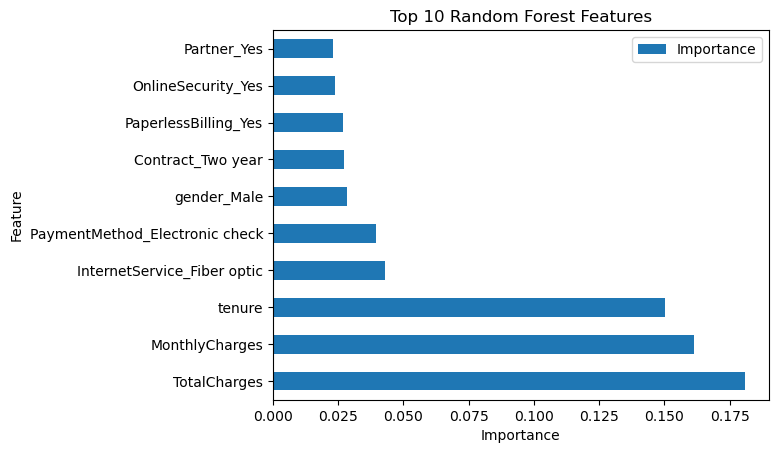

In [75]:
top_rf_features = rf_importance.head(10)

top_rf_features.plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Top 10 Random Forest Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [76]:
churn_probability = rf_model.predict_proba(X_test)[:, 1]

print(churn_probability[:10])

[0.    0.835 0.1   0.315 0.    0.41  0.335 0.09  0.005 0.455]


In [77]:
risk_category = pd.cut(
    churn_probability,
    bins=[0, 0.3, 0.7, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(risk_category.value_counts())

Low Risk       764
Medium Risk    399
High Risk      131
Name: count, dtype: int64


In [78]:
risk_summary = risk_category.value_counts().reset_index()

risk_summary.columns = ["Risk Category", "Customers"]

print(risk_summary)

  Risk Category  Customers
0      Low Risk        764
1   Medium Risk        399
2     High Risk        131


In [79]:
risk_summary.to_csv(
    "../data/processed/risk_summary.csv",
    index=False
)

print("Risk summary saved successfully!")

Risk summary saved successfully!


In [80]:
customer_predictions = data.iloc[y_test.index].copy()

customer_predictions["ChurnProbability"] = churn_probability
customer_predictions["RiskCategory"] = risk_category.astype(str)

customer_predictions.to_csv(
    "../data/processed/customer_churn_predictions.csv",
    index=False
)

print("Customer predictions saved successfully!")

Customer predictions saved successfully!


In [81]:
print("CUSTOMER CHURN ANALYSIS - FINAL SUMMARY")
print("---------------------------------------")
print("Total Customers:", len(data))
print("Overall Churn Rate:", round(churn_percentage["Yes"], 2), "%")
print("Logistic Regression Accuracy:", round(accuracy * 100, 2), "%")
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
print("High Risk Customers:", (risk_category == "High Risk").sum())

CUSTOMER CHURN ANALYSIS - FINAL SUMMARY
---------------------------------------
Total Customers: 7043
Overall Churn Rate: 26.54 %
Logistic Regression Accuracy: 79.91 %
Random Forest Accuracy: 78.85 %
High Risk Customers: 131
